links
<br>For colormaps and colorbars
<br>    - https://matplotlib.org/stable/tutorials/colors/colormaps.html
<br>    - https://matplotlib.org/3.2.2/gallery/userdemo/colormap_normalizations_diverging.html
<br>For projections
<br>    - https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html
<br>For features
<br>    - https://scitools.org.uk/cartopy/docs/v0.14/matplotlib/feature_interface.html
<br>How to get pcolormesh with levels (but didn't work)
<br>    - https://matplotlib.org/stable/gallery/images_contours_and_fields/pcolormesh_levels.html
    

In [25]:
import cartopy.util
import matplotlib.pyplot as plt
from netCDF4 import Dataset as netcdf_dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cmocean.cm as cmo

In [26]:
cmo.cmapnames

['thermal',
 'haline',
 'solar',
 'ice',
 'gray',
 'oxy',
 'deep',
 'dense',
 'algae',
 'matter',
 'turbid',
 'speed',
 'amp',
 'tempo',
 'rain',
 'phase',
 'topo',
 'balance',
 'delta',
 'curl',
 'diff',
 'tarn']

#########################################
<br>Plot precipitation for Europe alakeGLAC
<br>#########################################

[   0.   50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.
  600.  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150.
 1200.]


/home/csys/ukrebska/.conda/envs/lilly-paper/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: The following kwargs were not used by contour: 'interpolation'
  result = super().contour(*args, **kwargs)


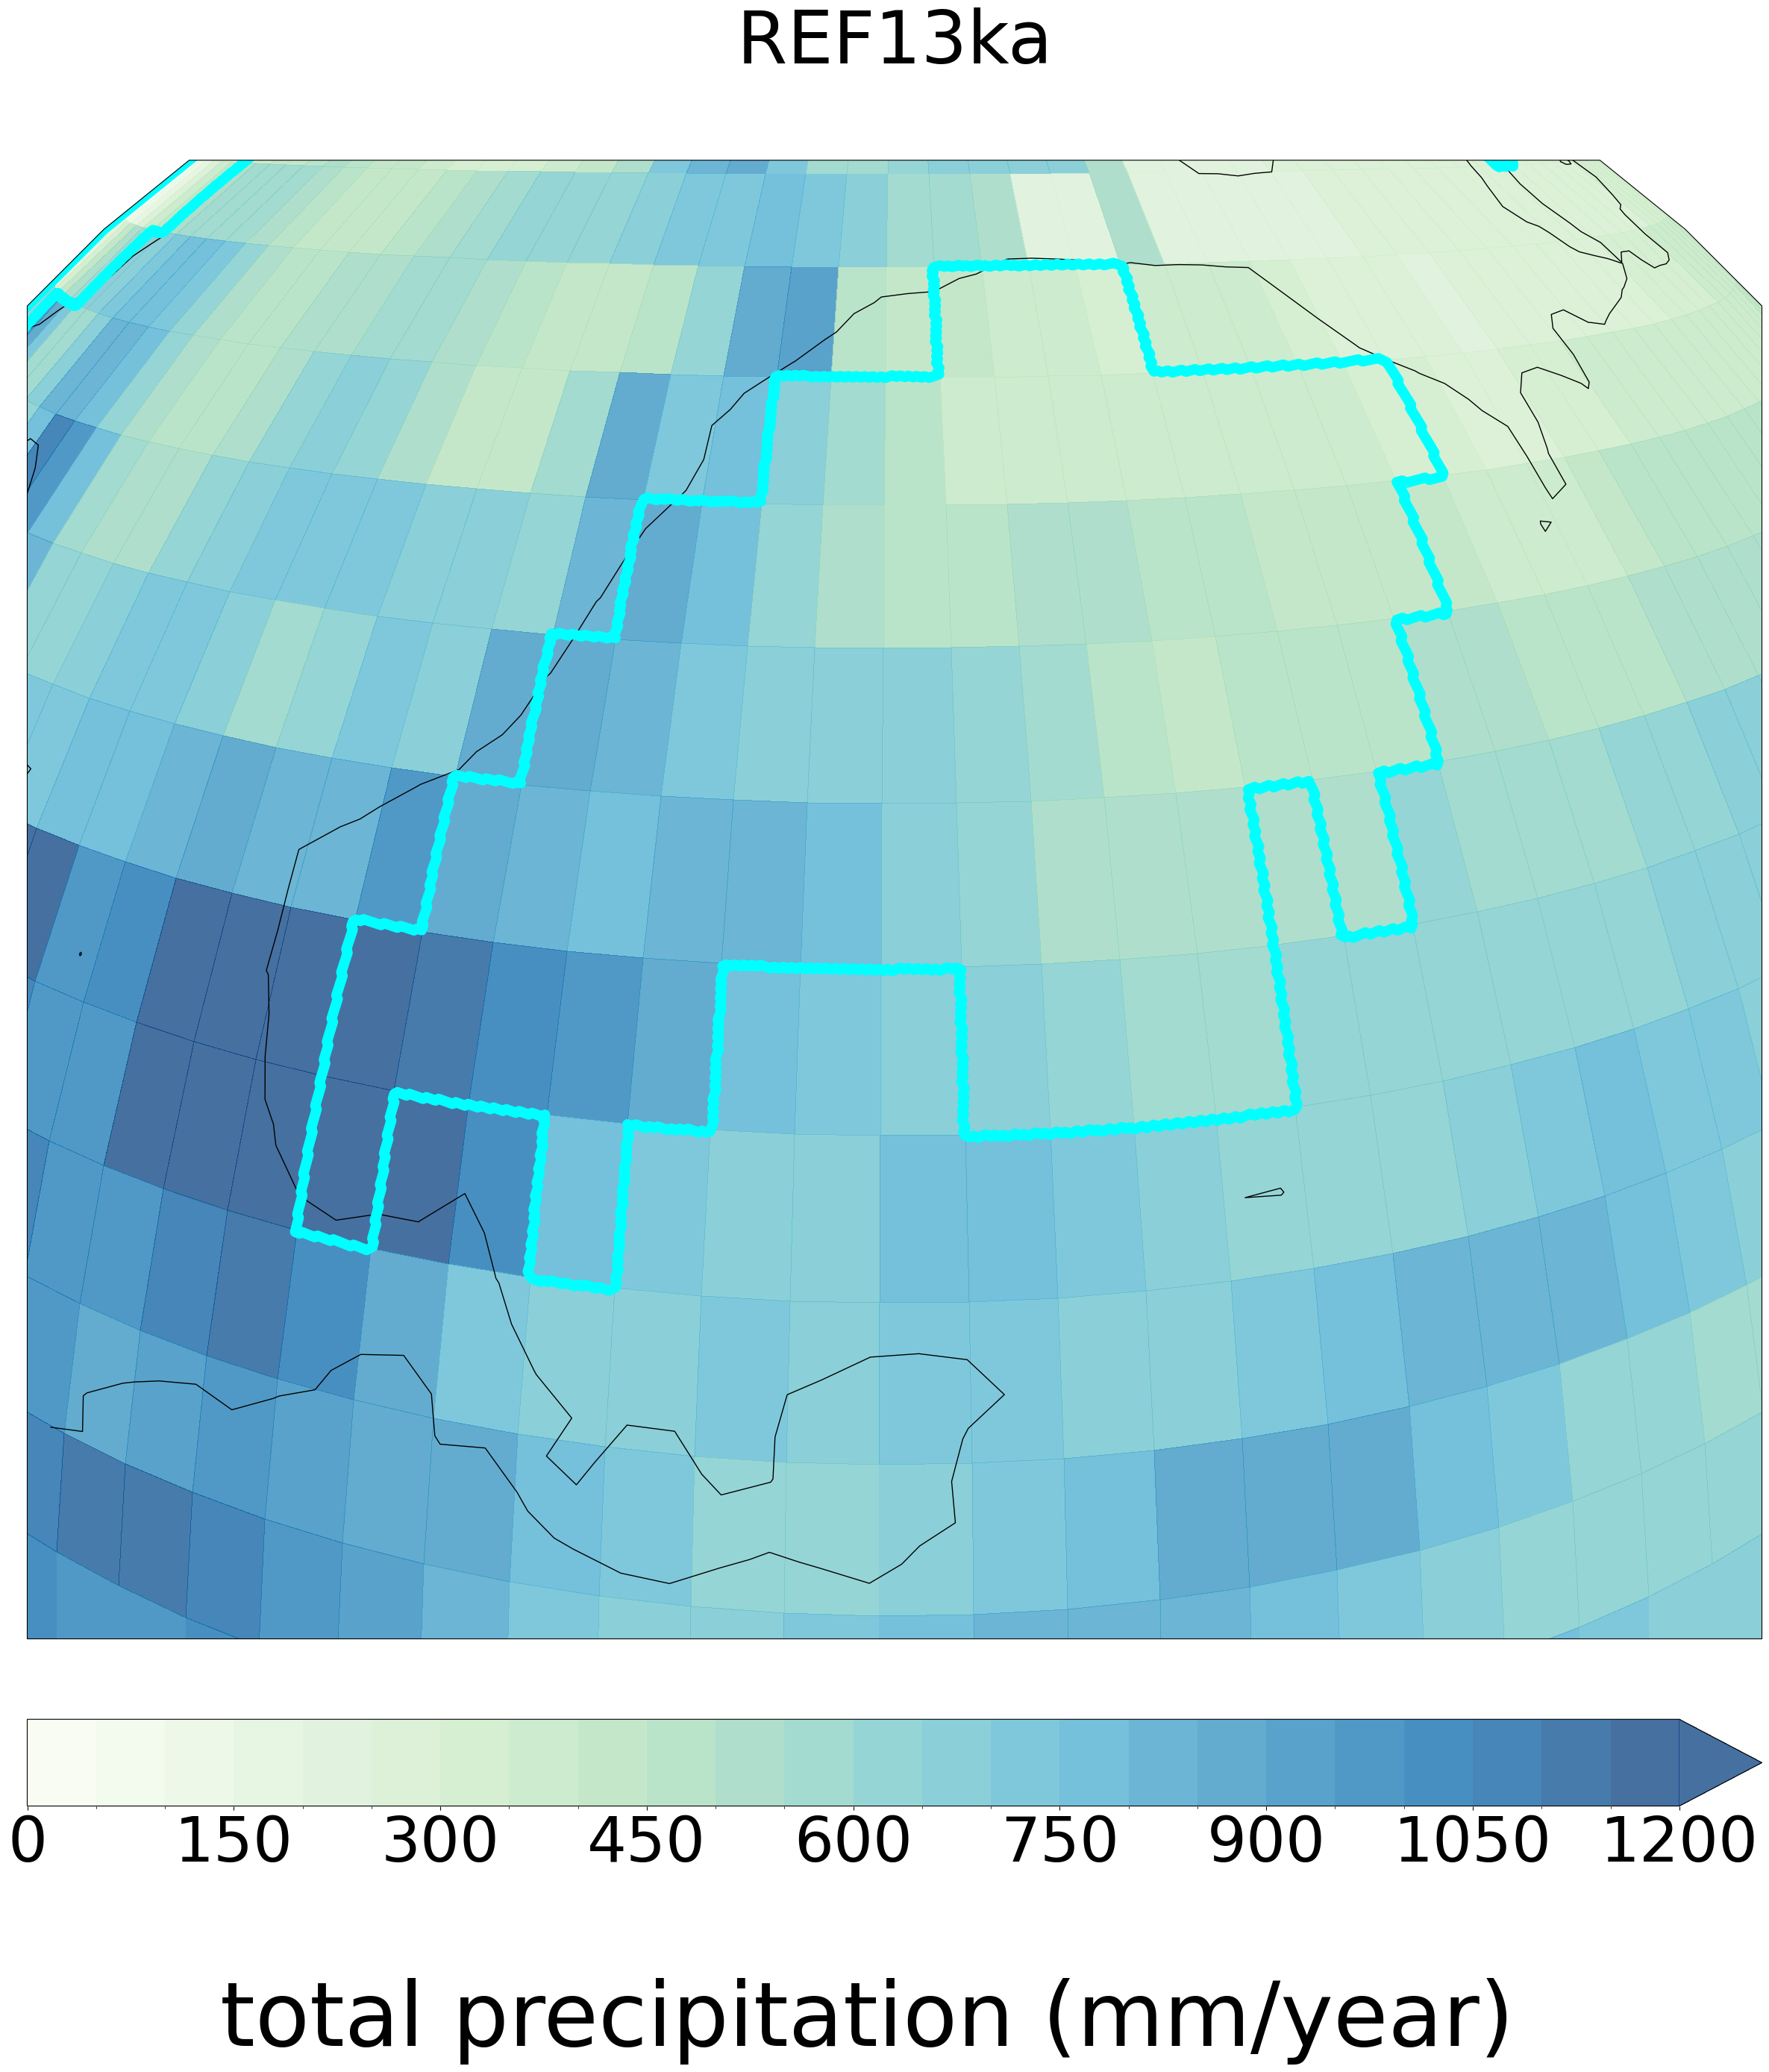

In [27]:
#read data
GLACL='../data/100ymean_alakeGLAC_precip_ym_2250_2349.nc'
GLACL_data=netcdf_dataset(GLACL)

BC='../data/bc_plake_nhem5km.nc' 
BC_data=netcdf_dataset(BC)
BCL='../data/TOPicemsk.15ka.nc' 
BCL_data=netcdf_dataset(BCL)


############################################
# create plot                              #
############################################


def makePlot(evar, clon, clat, extent, vlev, label):

    #Variable from alakeGLAC simulation (defined below)
    varg=GLACL_data.variables[evar][0,:,:]
    lats=GLACL_data.variables['lat'][:] 
    lons=GLACL_data.variables['lon'][:]

    #jansurf input on 5km grid used for debm
    glac=BC_data.variables['GLAC'][:]
    plake=BC_data.variables['PLAKE'][:]
    lats5=BC_data.variables['lat'][:] 
    lons5=BC_data.variables['lon'][:]
    
    
    #levtarasov input
    slm=BCL_data.variables['HDC'][0,:,:]
    llats=BCL_data.variables['YLATGLOBP5'][:] 
    llons=BCL_data.variables['XLONGLOB1'][:]
    
    
    #creates figure space
    fig_gp=plt.figure(figsize=(30,35))  #option to add integer, 1 will add this number to the figure and hold this number as an attribute
    
    #adds charts to figure
    g01=plt.subplot(111,projection=ccrs.NearsidePerspective(central_longitude=clon, central_latitude=clat, satellite_height=700_000)) 
    
    #sets the extent
    g01.set_extent(extent)
    
    #for better arrangement (less white space)
    #fig_gp.tight_layout()
    
    #for removing white space at 0 meridian when plotting echam6 data
    cyclic_datag, cyclic_lon = cartopy.util.add_cyclic_point(varg, coord=lons) 
    
    
    ################################
    #create year for alakeGLAC      #
    ################################
    
    #The following works with discrete colorbar, but has shitty ticks and no 0 in the middle
    bounds=np.linspace(level_min, level_max, 25)
    print(bounds)
    
    norm=mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
    
    g01_fill=g01.pcolormesh(lons, lats, varg,
                            transform=ccrs.PlateCarree(),
                            norm=norm,
                            cmap="GnBu",
                            alpha=0.75
                           )

    
    g01_cbar=plt.colorbar(g01_fill, ax=g01,
                          orientation='horizontal',       
                          fraction=0.05, pad=0.04,
                          extend="max",
                          boundaries=bounds
                         )  
    
    ############
    #boundaries# 
    ############

    g01_slm=g01.contour(llons, llats, slm,
                        transform=ccrs.PlateCarree(),
                        interpolation="none", #why doesn't it affect plot??
                        levels=[0],
                        colors="black",
                        linewidths=1,
                        linestyles=["-"],
                        )        
    g01_gla=g01.contour(lons5, lats5, glac,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="cyan",
                        linewidths=10,
                        linestyles=["-"],
                       )
    g01.set_title(" REF13ka \n"
                  "",
                  fontsize=70
                 )
    g01_cbar.ax.tick_params(labelsize=60)
    g01_cbar.set_label(label, fontsize=86)
  
    fig_gp.savefig('../FIGS/Fig2_1.png')

    return

var_extent= [0,40,52,73]
level_min=0
level_max=1200
stepsize=50
var_levels=np.arange(level_min,level_max,stepsize)
season="year"

makePlot(evar='precip', 
         clon=20,
         clat=60, 
         extent=var_extent,
         vlev = var_levels,
         label = "\n total precipitation (mm/"+season+")"
        )


#########################################
<br>Plot precipitation anomaly for Europe
<br>#########################################

[-175. -150. -125. -100.  -75.  -50.  -25.    0.   25.   50.   75.  100.
  125.  150.  175.]


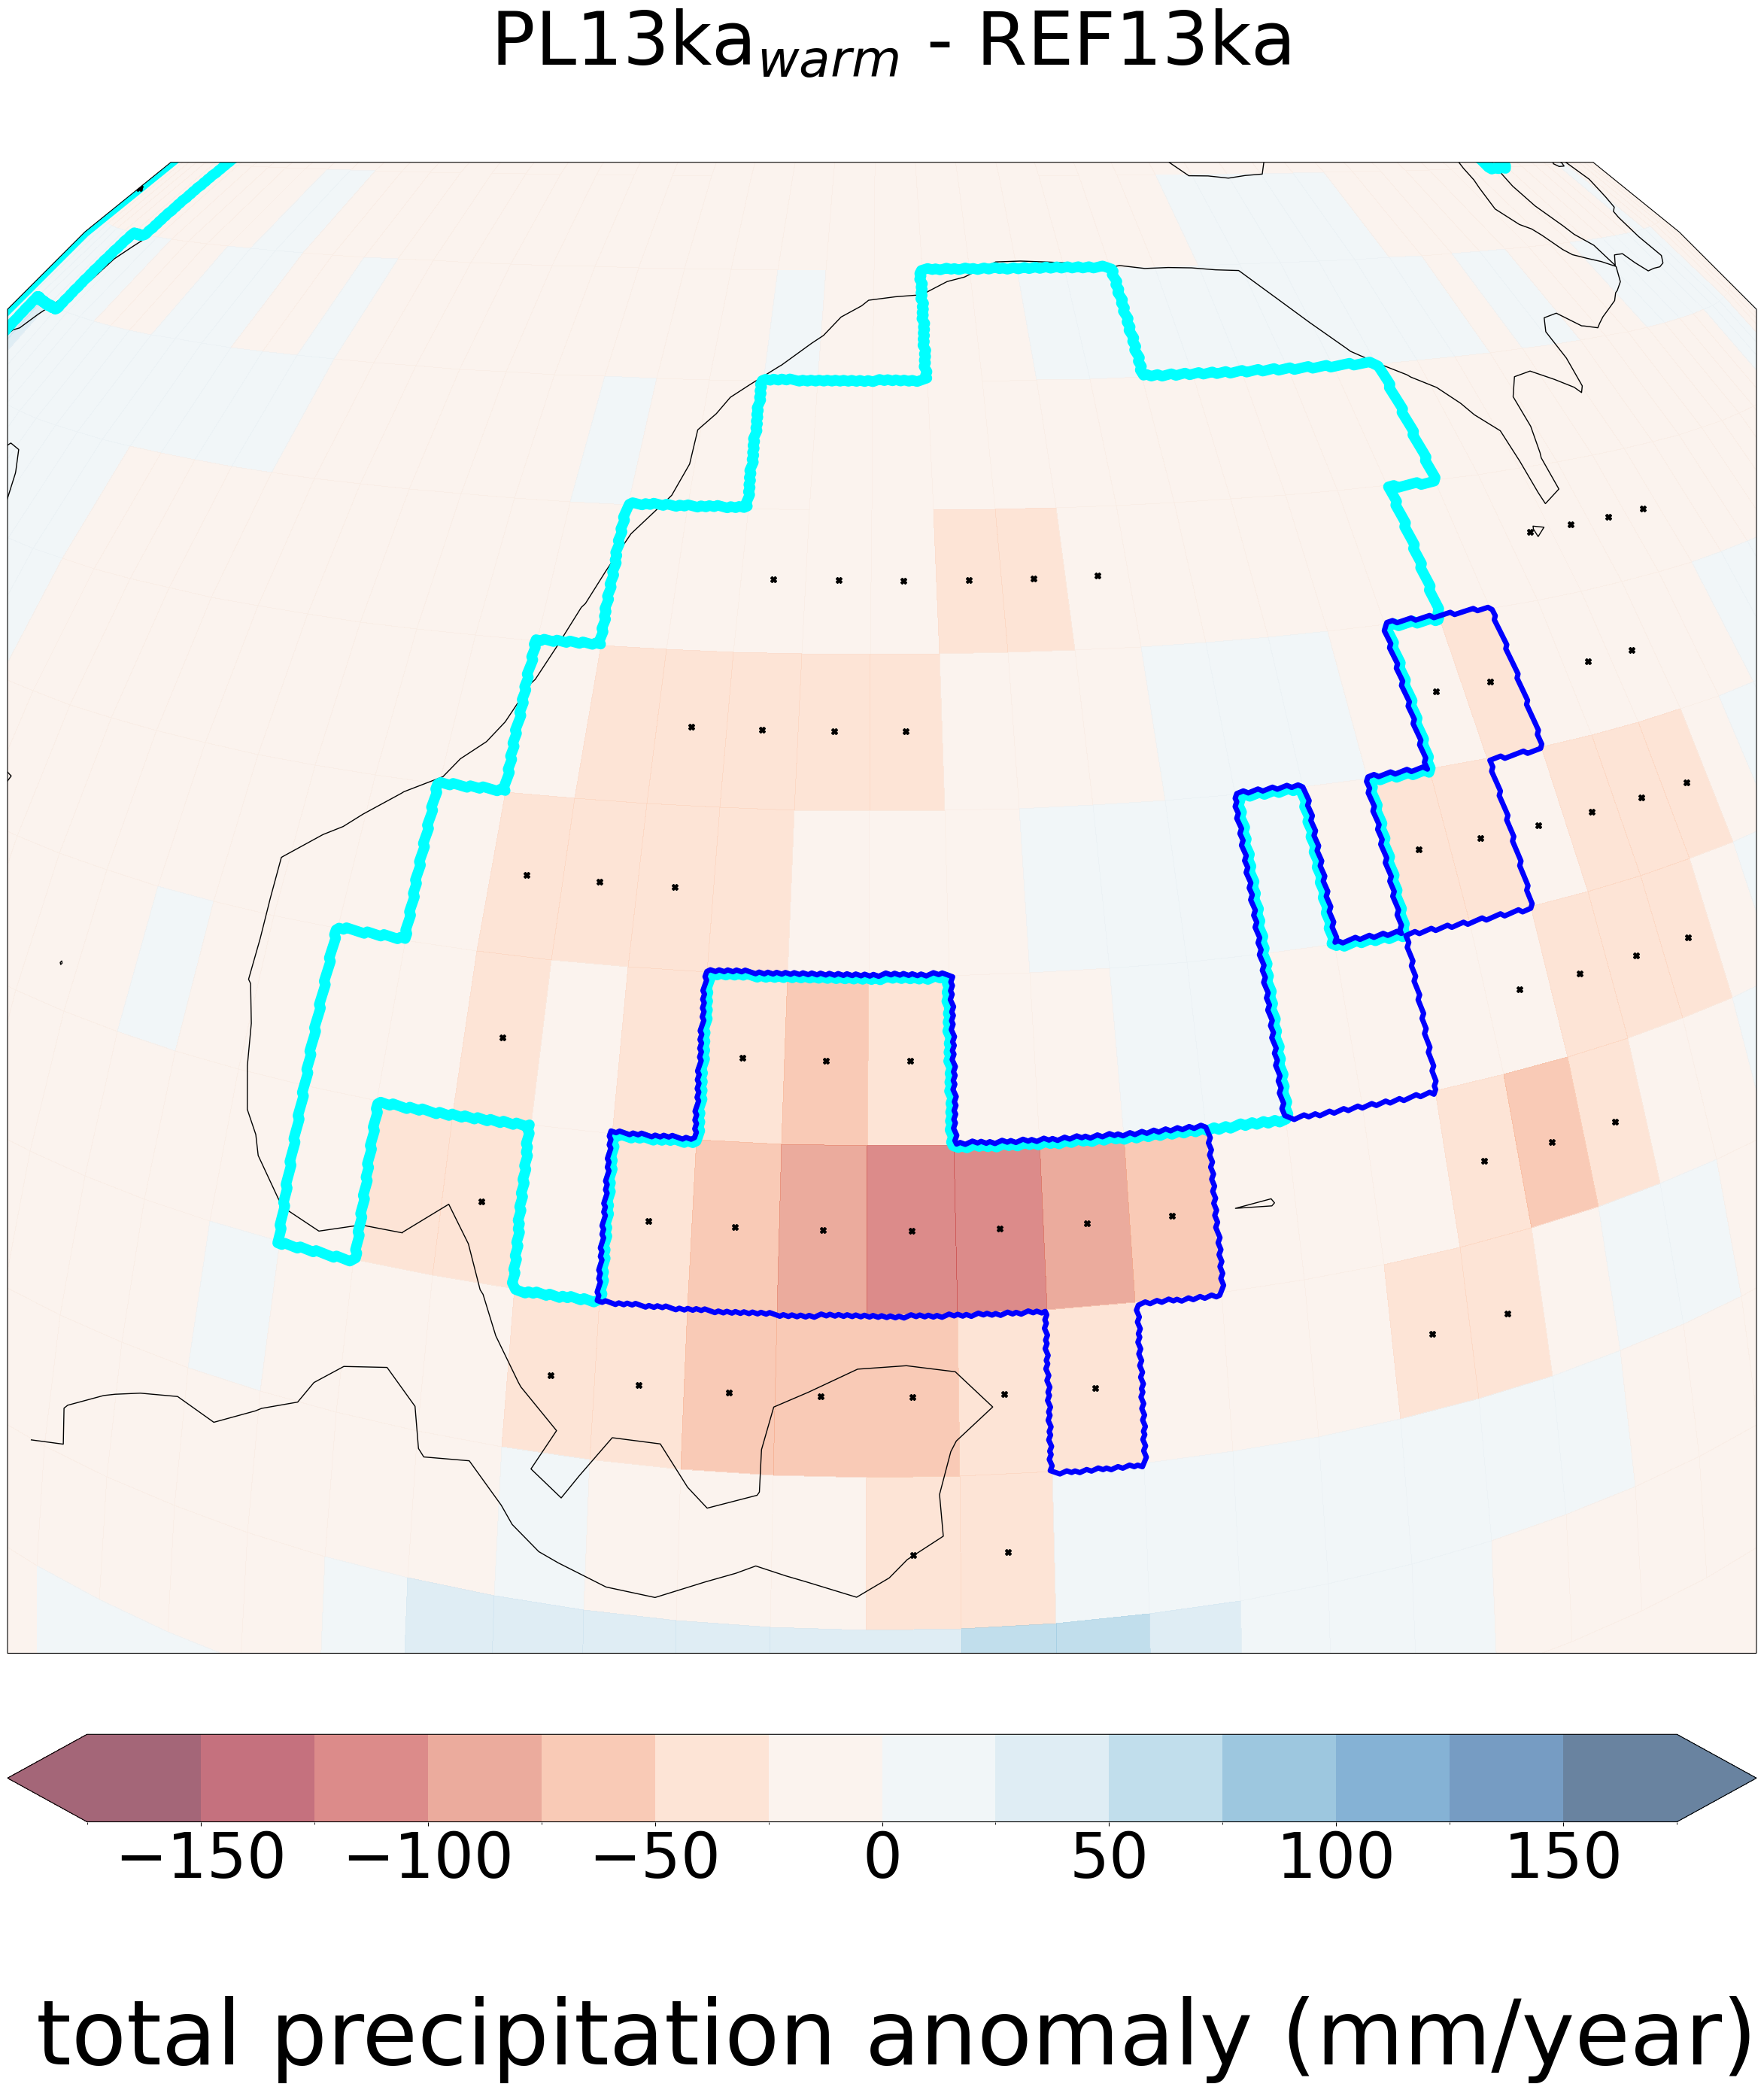

In [28]:
#read data Fig1_6
PLAKE='../data/100ymean_alake13ka_precip_ym_2250_2349.nc'
PLAKE_data=netcdf_dataset(PLAKE)
GLACL='../data/100ymean_alakeGLAC_precip_ym_2250_2349.nc'
GLACL_data=netcdf_dataset(GLACL)

BC='../data/bc_plake_nhem5km.nc' 
BC_data=netcdf_dataset(BC)
BCL='../data/TOPicemsk.15ka.nc' 
BCL_data=netcdf_dataset(BCL)

PSIG='../data/AL_SigMaskSM.nc'
PSIG_data=netcdf_dataset(PSIG)

############################################
# create plot                              #
############################################


def makePlot(evar, clon, clat, extent, vlev, label):

    #Variable from alakeGLAC simulation (defined below)
    varp=PLAKE_data.variables[evar][0,:,:]
    varg=GLACL_data.variables[evar][0,:,:]
    lats=GLACL_data.variables['lat'][:] 
    lons=GLACL_data.variables['lon'][:]

    #jansurf input on 5km grid used for debm
    glac=BC_data.variables['GLAC'][:]
    plake=BC_data.variables['PLAKE'][:]
    lats5=BC_data.variables['lat'][:] 
    lons5=BC_data.variables['lon'][:]
    
    #levtarasov input
    slm=BCL_data.variables['HDC'][0,:,:]
    llats=BCL_data.variables['YLATGLOBP5'][:] 
    llons=BCL_data.variables['XLONGLOB1'][:]
    #significance mask
    vsigp=PSIG_data.variables['prcip_mask'][:,:] 

    #creates figure space
    fig_gp=plt.figure(figsize=(30,35))  #option to add integer, 1 will add this number to the figure and hold this number as an attribute
    
    #adds charts to figure
    p01=plt.subplot(111,projection=ccrs.NearsidePerspective(central_longitude=clon, central_latitude=clat, satellite_height=700_000)) 
    
    #sets the extent
    p01.set_extent(extent)
    
    
    ####################################
    #create anomaly for plake-alakeGLAC#
    #################################### 
    
    
    #The following works with discrete colorbar, but has shitty ticks and no 0 in the middle
    bounds=np.linspace(level_min, level_max, 15)
    print(bounds)
    
    norm=mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
    
    p01_fill=p01.pcolormesh(lons, lats, (varp-varg),
                            transform=ccrs.PlateCarree(),
                            norm=norm,
                            cmap="RdBu", #cmo.balance,
                            alpha=0.6,
                            edgecolor="none"
                           )

    
    p01_cbar=plt.colorbar(p01_fill, ax=p01,
                          orientation='horizontal',       
                          fraction=0.05, pad=0.04,
                          extend="both",
                          boundaries=bounds
                         )  
    
    ############
    #boundaries# 
    ############

    p01_slm=p01.contour(llons, llats, slm,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="black",
                        linewidths=1,
                        linestyles=["-"],
                        )        
    p01_gla=p01.contour(lons5, lats5, glac,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="cyan",
                        linewidths=10,
                        linestyles=["-"],
                        )  
    p01_plk=p01.contour(lons5, lats5, plake,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="blue",
                        linewidths=5,
                        linestyles=["-"],
                        #linestyles=["-."],
                        )
    for idx, lon_val in enumerate(lons):
        for idy, lat_val in enumerate(lats):
            if (vsigp[idy, idx]==0):
                p01.plot(lon_val, lat_val, 'kX',
                        transform=ccrs.PlateCarree())
    
                p01.set_title(" PL13ka$_{warm}$ - REF13ka \n"
                  "",
                  fontsize=70
                 )
    p01_cbar.ax.tick_params(labelsize=60)
    p01_cbar.set_label(label, fontsize=86)
    
    fig_gp.savefig('../FIGS/Fig2_2.png')

    
    return

var_extent= [0,40,52,73]
level_min=-175
level_max=175
stepsize=25
var_levels2=np.arange(level_min,level_max,stepsize)
season="year"


makePlot(evar='precip', 
         clon=20,
         clat=60, 
         extent=var_extent,
         vlev = var_levels2,
         label = "\n total precipitation anomaly (mm/"+season+")"
        )

[-175. -150. -125. -100.  -75.  -50.  -25.    0.   25.   50.   75.  100.
  125.  150.  175.]


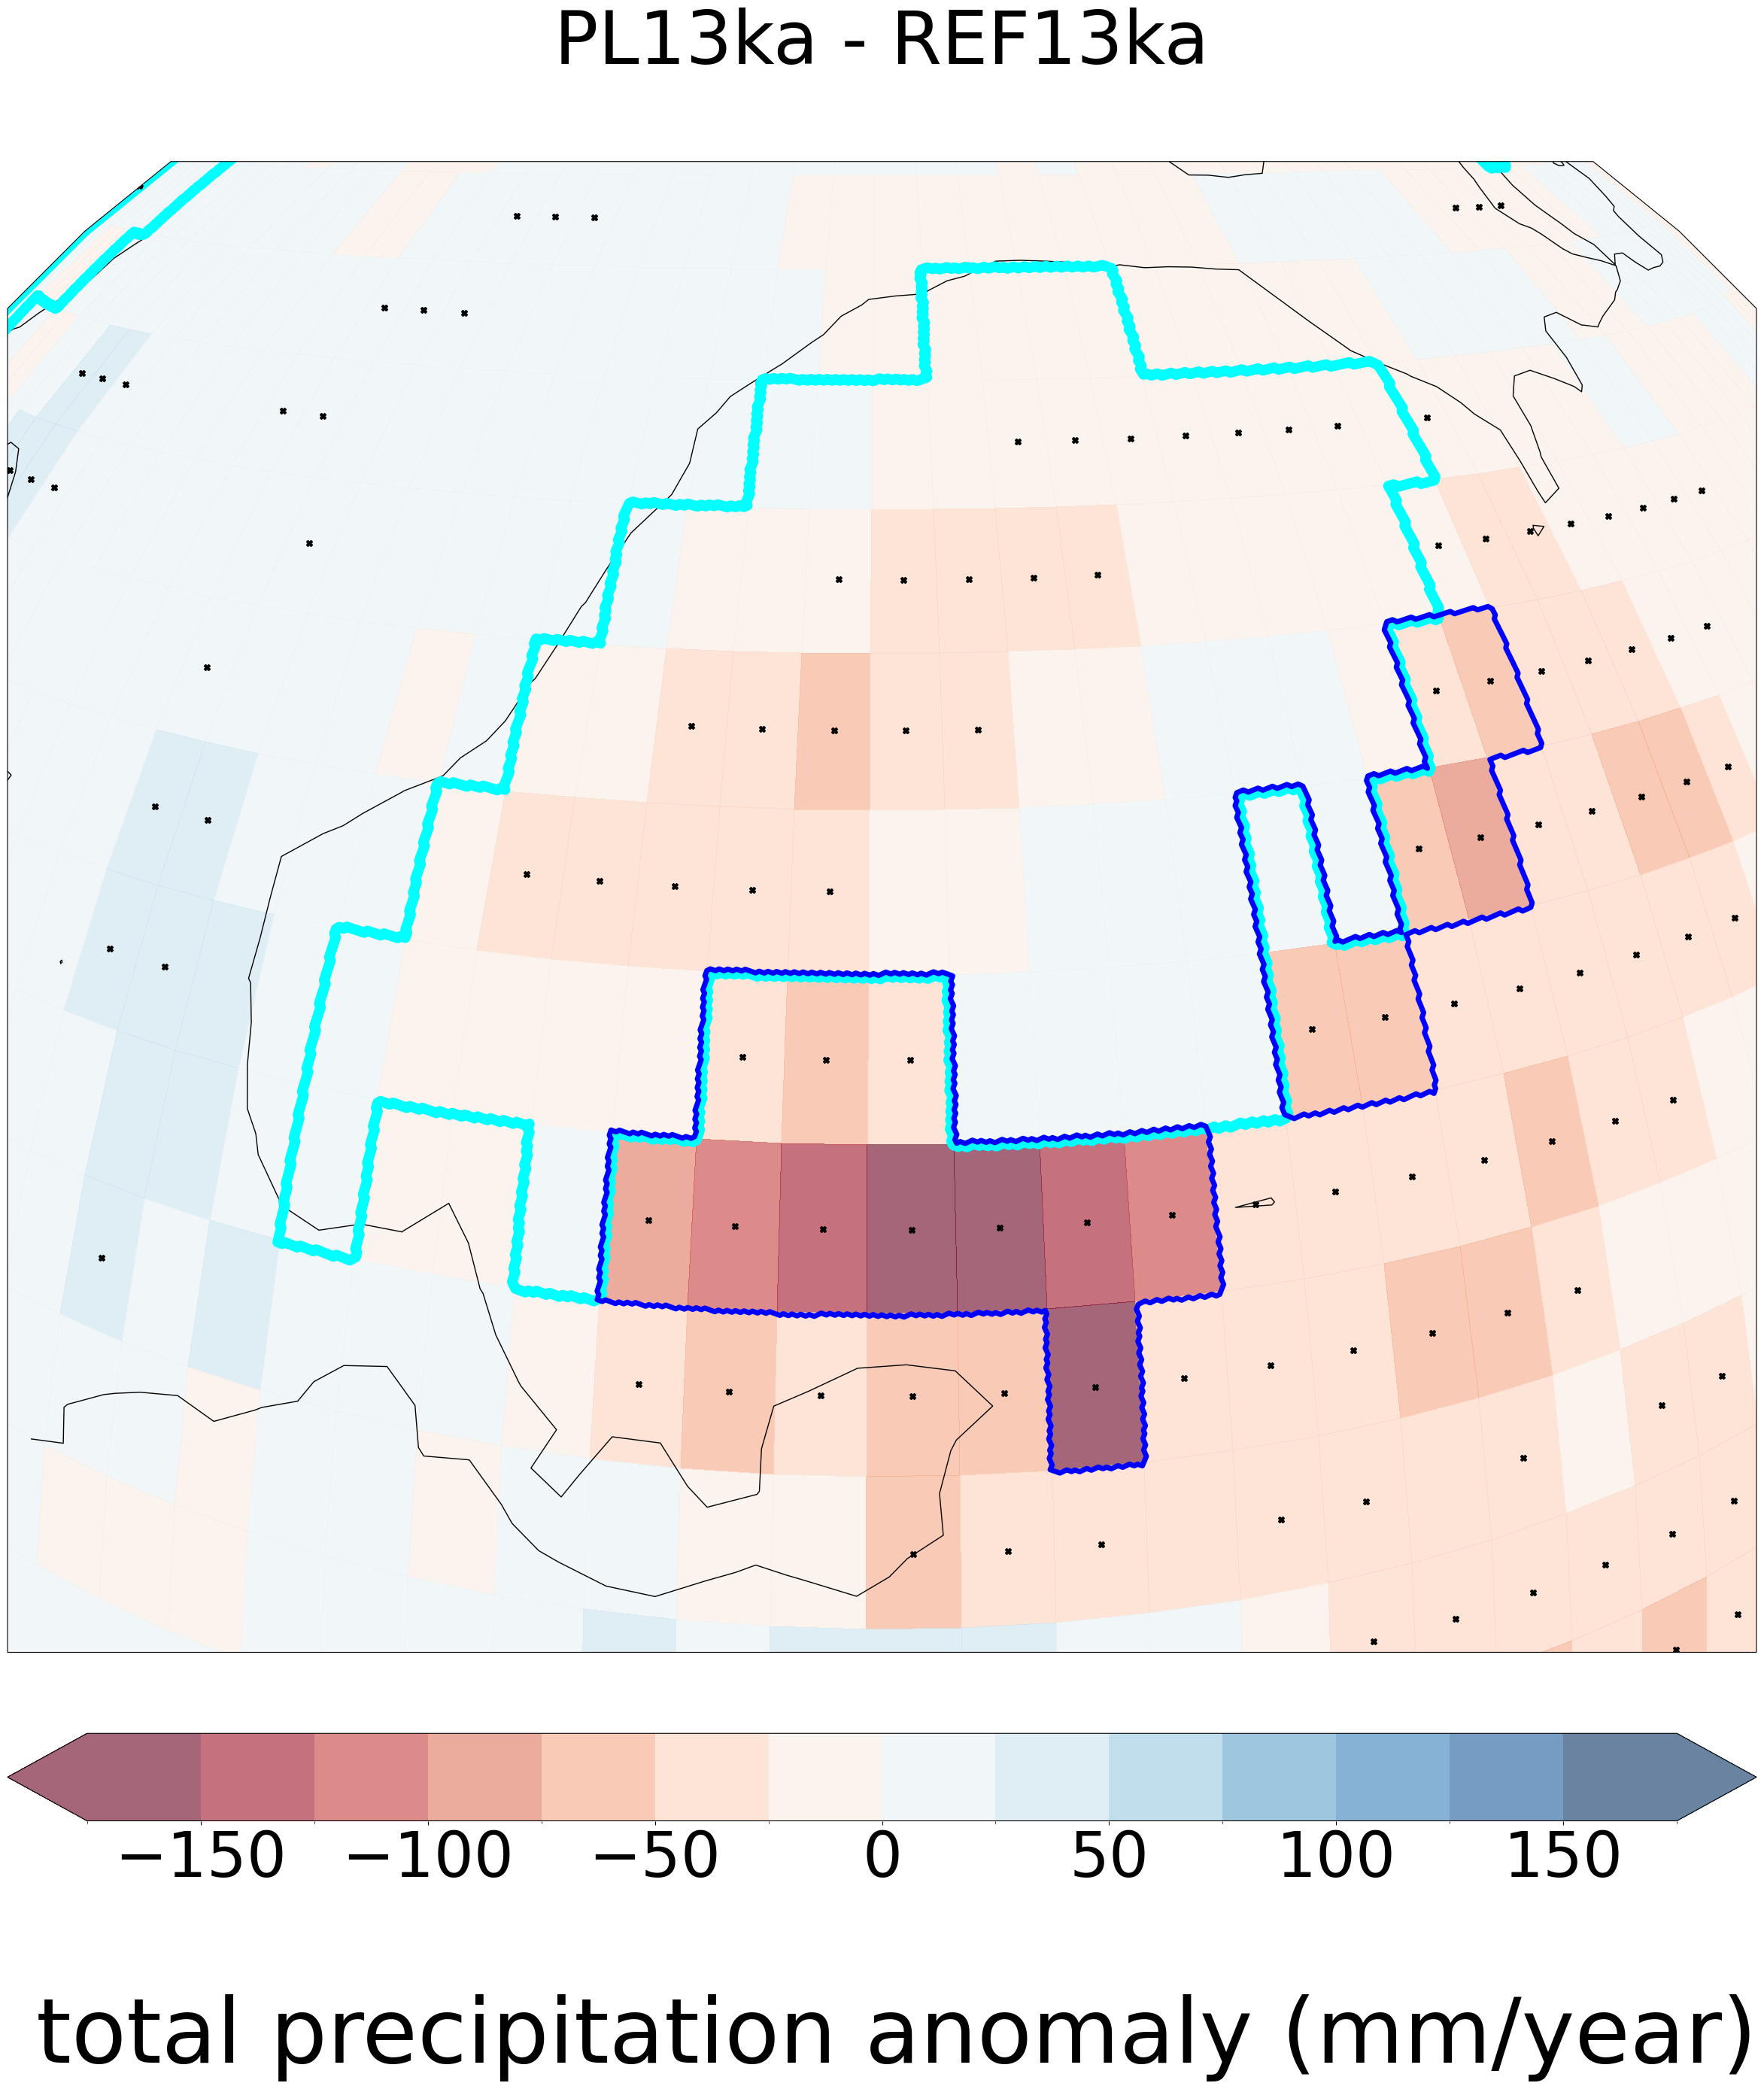

In [29]:
#read data Fig1_6
PLAKE='../data/100ymean_plake_precip_ym_2250_2349.nc'
PLAKE_data=netcdf_dataset(PLAKE)
GLACL='../data/100ymean_alakeGLAC_precip_ym_2250_2349.nc'
GLACL_data=netcdf_dataset(GLACL)

BC='../data/bc_plake_nhem5km.nc' 
BC_data=netcdf_dataset(BC)
BCL='../data/TOPicemsk.15ka.nc' 
BCL_data=netcdf_dataset(BCL)

PSIG='../data/PL_SigMaskSM.nc'
PSIG_data=netcdf_dataset(PSIG)

############################################
# create plot                              #
############################################


def makePlot(evar, clon, clat, extent, vlev, label):

    #Variable from alakeGLAC simulation (defined below)
    varp=PLAKE_data.variables[evar][0,:,:]
    varg=GLACL_data.variables[evar][0,:,:]
    lats=GLACL_data.variables['lat'][:] 
    lons=GLACL_data.variables['lon'][:]

    #jansurf input on 5km grid used for debm
    glac=BC_data.variables['GLAC'][:]
    plake=BC_data.variables['PLAKE'][:]
    lats5=BC_data.variables['lat'][:] 
    lons5=BC_data.variables['lon'][:]
    
    #levtarasov input
    slm=BCL_data.variables['HDC'][0,:,:]
    llats=BCL_data.variables['YLATGLOBP5'][:] 
    llons=BCL_data.variables['XLONGLOB1'][:]
    #significance mask
    vsigp=PSIG_data.variables['prcip_mask'][:,:] 

    #creates figure space
    fig_gp=plt.figure(figsize=(30,35))  #option to add integer, 1 will add this number to the figure and hold this number as an attribute
    
    #adds charts to figure
    p01=plt.subplot(111,projection=ccrs.NearsidePerspective(central_longitude=clon, central_latitude=clat, satellite_height=700_000)) 
    
    #sets the extent
    p01.set_extent(extent)
    
    
    ####################################
    #create anomaly for plake-alakeGLAC#
    #################################### 
    
    
    #The following works with discrete colorbar, but has shitty ticks and no 0 in the middle
    bounds=np.linspace(level_min, level_max, 15)
    print(bounds)
    
    norm=mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
    
    p01_fill=p01.pcolormesh(lons, lats, (varp-varg),
                            transform=ccrs.PlateCarree(),
                            norm=norm,
                            cmap="RdBu", #cmo.balance,
                            alpha=0.6,
                            edgecolor="none"
                           )

    
    p01_cbar=plt.colorbar(p01_fill, ax=p01,
                          orientation='horizontal',       
                          fraction=0.05, pad=0.04,
                          extend="both",
                          boundaries=bounds
                         )  
    
    ############
    #boundaries# 
    ############

    p01_slm=p01.contour(llons, llats, slm,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="black",
                        linewidths=1,
                        linestyles=["-"],
                        )        
    p01_gla=p01.contour(lons5, lats5, glac,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="cyan",
                        linewidths=10,
                        linestyles=["-"],
                        )  
    p01_plk=p01.contour(lons5, lats5, plake,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="blue",
                        linewidths=5,
                        linestyles=["-"],
                        #linestyles=["-."],
                        )
    for idx, lon_val in enumerate(lons):
        for idy, lat_val in enumerate(lats):
            if (vsigp[idy, idx]==0):
                p01.plot(lon_val, lat_val, 'kX',
                        transform=ccrs.PlateCarree())
    
                p01.set_title(" PL13ka - REF13ka \n"
                  "",
                  fontsize=70
                 )
    p01_cbar.ax.tick_params(labelsize=60)
    p01_cbar.set_label(label, fontsize=86)
    
    fig_gp.savefig('../FIGS/Fig2_3.png')

    
    return

var_extent= [0,40,52,73]
level_min=-175
level_max=175
stepsize=25
var_levels2=np.arange(level_min,level_max,stepsize)
season="year"


makePlot(evar='precip', 
         clon=20,
         clat=60, 
         extent=var_extent,
         vlev = var_levels2,
         label = "\n total precipitation anomaly (mm/"+season+")"
        )

#########################################
<br>Plot precipitation for NA alakeGLAC
<br>#########################################

[   0.   50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.
  600.  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150.
 1200.]


/home/csys/ukrebska/.conda/envs/lilly-paper/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: The following kwargs were not used by contour: 'interpolation'
  result = super().contour(*args, **kwargs)


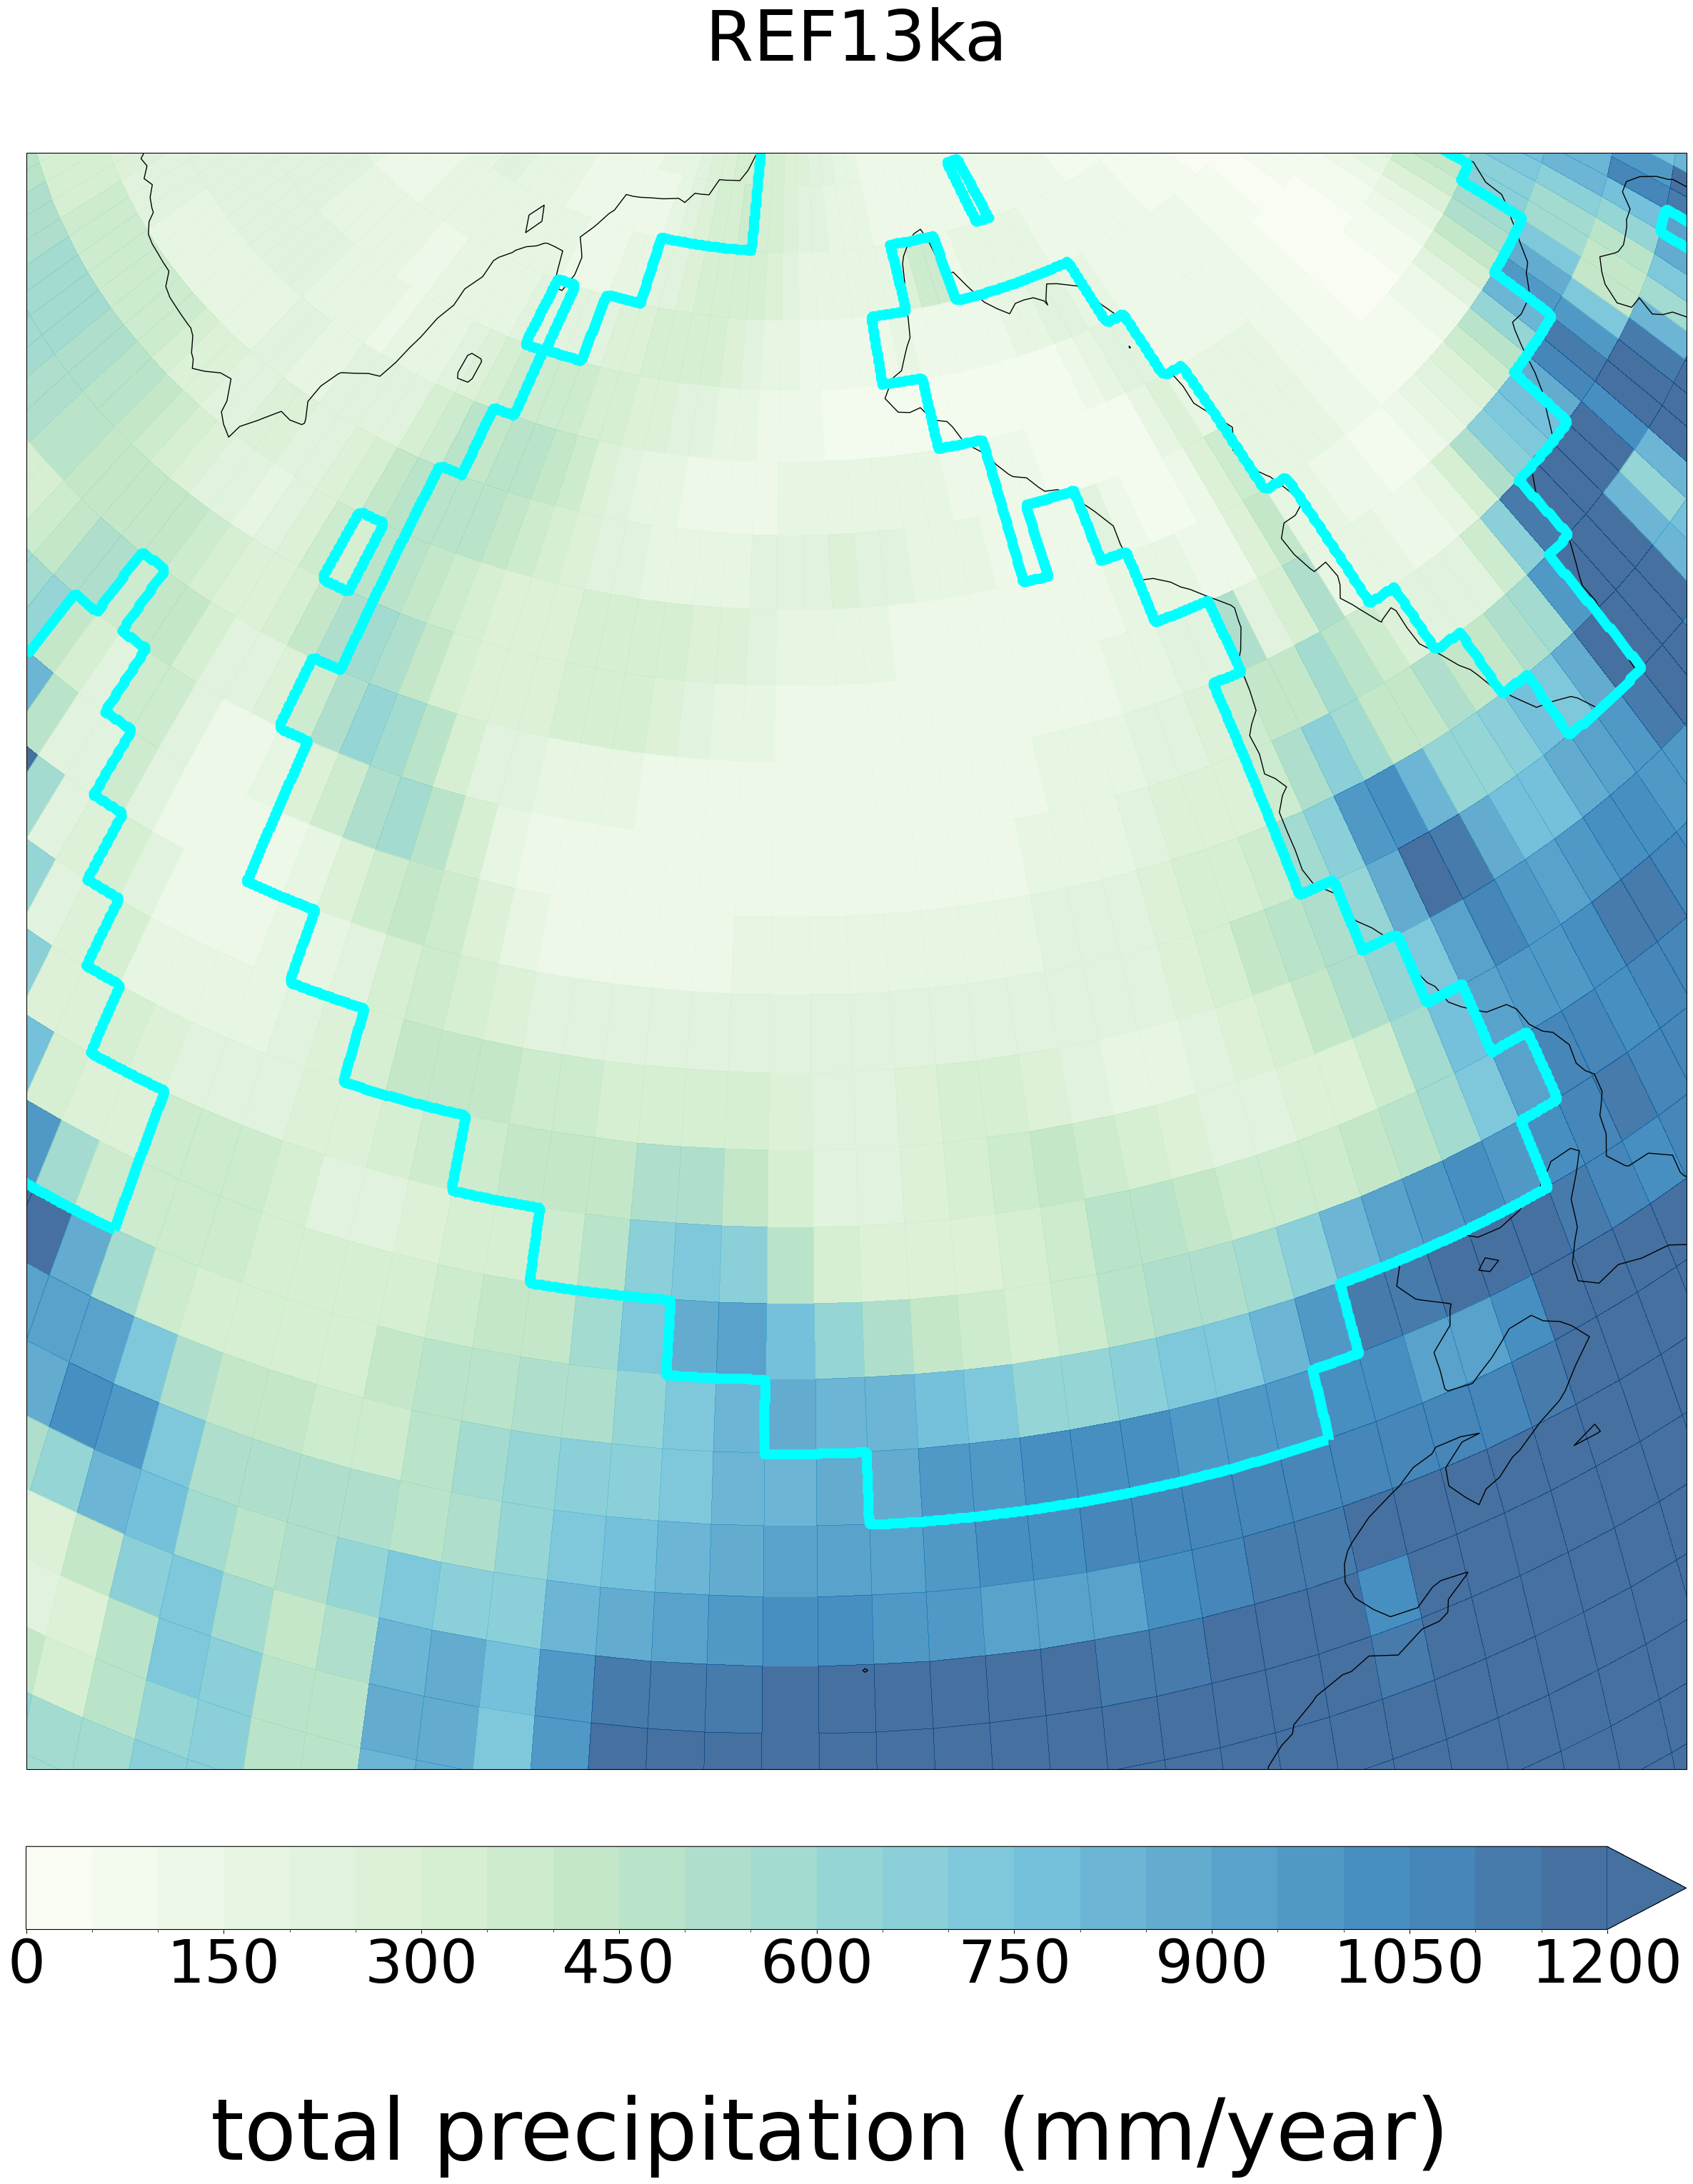

In [30]:
#read data
PLAKE='../data/100ymean_plake_precip_ym_2250_2349.nc'
PLAKE_data=netcdf_dataset(PLAKE)
GLACL='../data/100ymean_alakeGLAC_precip_ym_2250_2349.nc'
GLACL_data=netcdf_dataset(GLACL)

BC='../data/bc_plake_nhem5km.nc' 
BC_data=netcdf_dataset(BC)
BCL='../data/TOPicemsk.15ka.nc' 
BCL_data=netcdf_dataset(BCL)

PSIG='../data/AL_SigMaskSM.nc'
PSIG_data=netcdf_dataset(PSIG)

############################################
# create plot                              #
############################################


def makePlot(evar, clon, clat, extent, label):

    #Variable from alakeGLAC simulation (defined below)
    varg=GLACL_data.variables[evar][0,:,:]
    lats=GLACL_data.variables['lat'][:] 
    lons=GLACL_data.variables['lon'][:]

    #jansurf input on 5km grid used for debm
    glac=BC_data.variables['GLAC'][:]
    plake=BC_data.variables['PLAKE'][:]
    lats5=BC_data.variables['lat'][:] 
    lons5=BC_data.variables['lon'][:]
    
    
    #levtarasov input
    slm=BCL_data.variables['HDC'][0,:,:]
    llats=BCL_data.variables['YLATGLOBP5'][:] 
    llons=BCL_data.variables['XLONGLOB1'][:]
    
    

    #creates figure space
    fig_gp=plt.figure(figsize=(30,35))  #option to add integer, 1 will add this number to the figure and hold this number as an attribute
    
    #adds charts to figure
    g01=plt.subplot(111,projection=ccrs.NearsidePerspective(central_longitude=clon, central_latitude=clat, satellite_height=10_000_000)) 
    
    #sets the extent
    g01.set_extent(extent)
    
    
    ################################
    #create year for alakeGLAC      #
    ################################
    
    #The following works with discrete colorbar, but has shitty ticks and no 0 in the middle
    bounds=np.linspace(level_min, level_max, 25)
    print(bounds)
    
    norm=mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
    
    g01_fill=g01.pcolormesh(lons, lats, varg,
                            transform=ccrs.PlateCarree(),
                            norm=norm,
                            cmap="GnBu",
                            alpha=0.75
                           )

    
    g01_cbar=plt.colorbar(g01_fill, ax=g01,
                          orientation='horizontal',       
                          fraction=0.05, pad=0.04,
                          extend="max",
                          boundaries=bounds
                         )  
    
    ############
    #boundaries# 
    ############

    g01_slm=g01.contour(llons, llats, slm,
                        transform=ccrs.PlateCarree(),
                        interpolation="none", #why doesn't it affect plot??
                        levels=[0],
                        colors="black",
                        linewidths=1,
                        linestyles=["-"],
                        )        
    g01_gla=g01.contour(lons5, lats5, glac,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="cyan",
                        linewidths=10,
                        linestyles=["-"]
                        )
    
    g01.set_title(" REF13ka \n"
                  "",
                  fontsize=70
                 )
    g01_cbar.ax.tick_params(labelsize=60)
    g01_cbar.set_label(label, fontsize=86)
    
    fig_gp.savefig('../FIGS/Fig2_4.png')
    return

var_extent= [-115,-60,35,80]
level_min=0
level_max=1200
stepsize=50
var_levels=np.arange(level_min,level_max,stepsize)
season="year"

makePlot(evar='precip', 
         clon=-90,
         clat=60, 
         extent=var_extent,
         label = "\n total precipitation (mm/"+season+")"
        )

#########################################
<br>Plot precipitation anomaly for NA
<br>#########################################

[-175. -150. -125. -100.  -75.  -50.  -25.    0.   25.   50.   75.  100.
  125.  150.  175.]


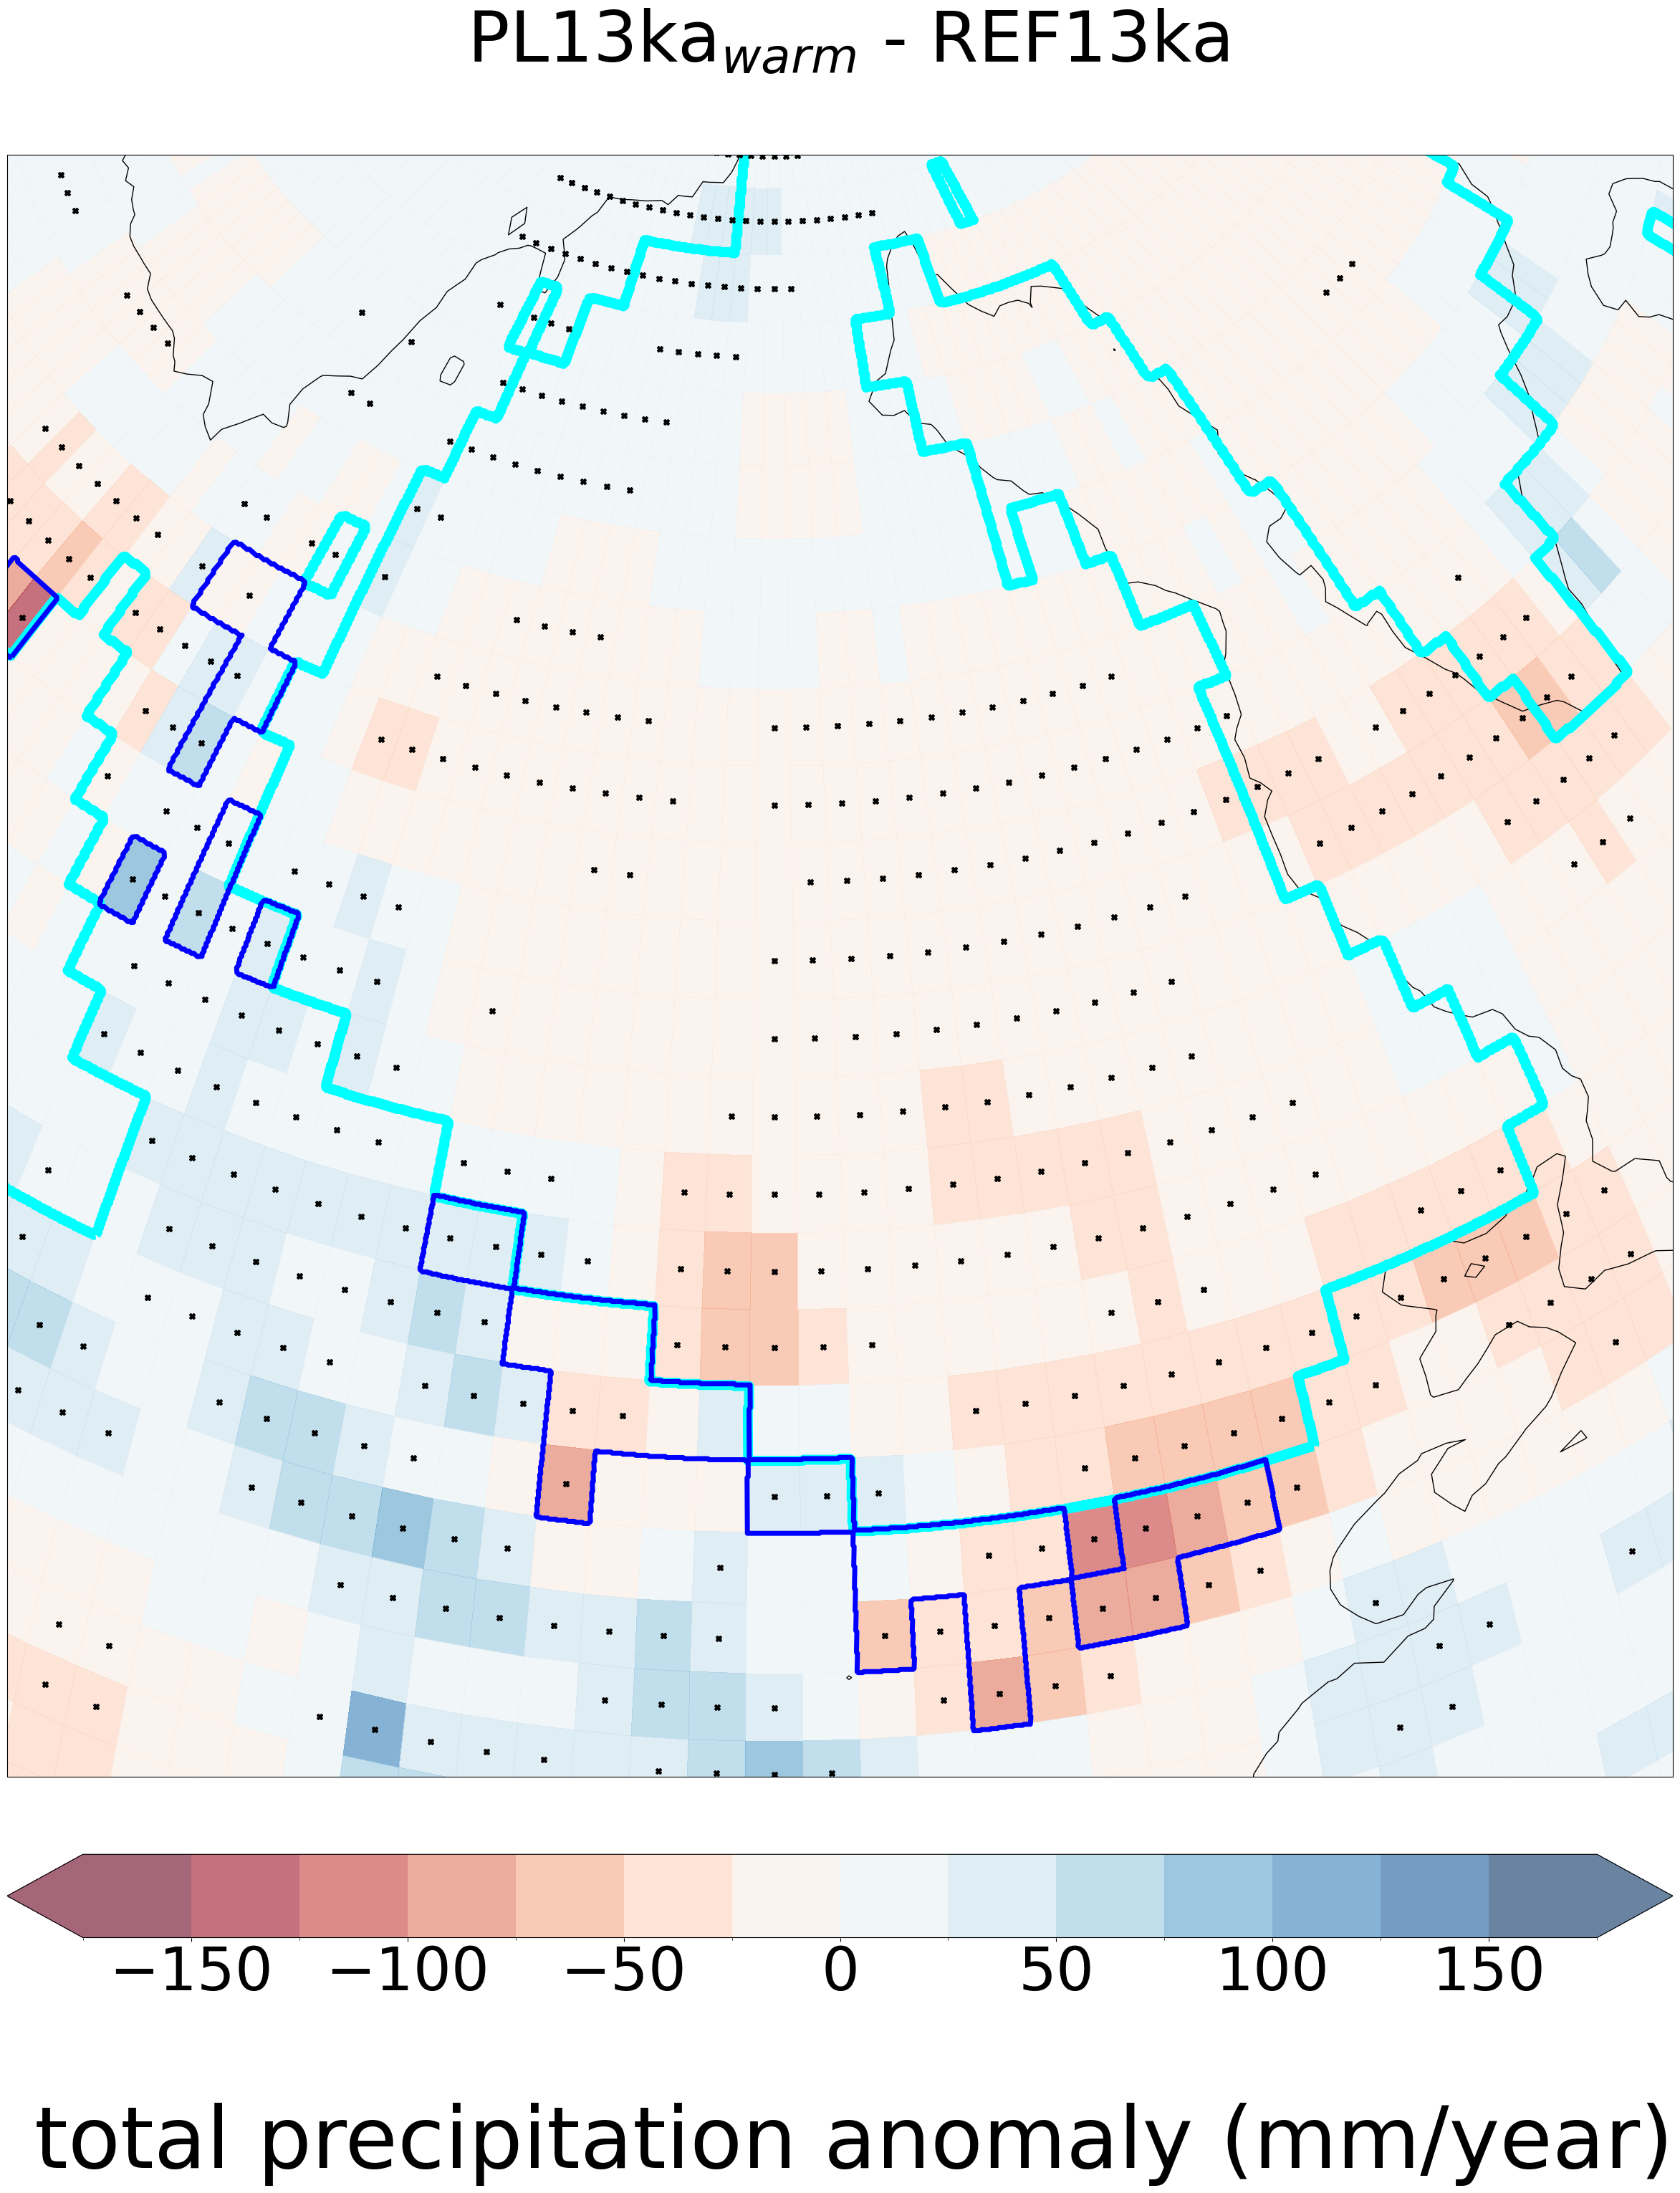

In [31]:
#read data

PLAKE='../data/100ymean_alake13ka_precip_ym_2250_2349.nc'
PLAKE_data=netcdf_dataset(PLAKE)
GLACL='../data/100ymean_alakeGLAC_precip_ym_2250_2349.nc'
GLACL_data=netcdf_dataset(GLACL)

BC='../data/bc_plake_nhem5km.nc' 
BC_data=netcdf_dataset(BC)
BCL='../data/TOPicemsk.15ka.nc' 
BCL_data=netcdf_dataset(BCL)

PSIG='../data/AL_SigMaskSM.nc'
PSIG_data=netcdf_dataset(PSIG)
############################################
# create plot                              #
############################################


def makePlot(evar, clon, clat, extent, label):

    #Variable from alakeGLAC simulation (defined below)
    varp=PLAKE_data.variables[evar][0,:,:]
    varg=GLACL_data.variables[evar][0,:,:]
    lats=GLACL_data.variables['lat'][:] 
    lons=GLACL_data.variables['lon'][:]

    #jansurf input on 5km grid used for debm
    glac=BC_data.variables['GLAC'][:]
    plake=BC_data.variables['PLAKE'][:]
    lats5=BC_data.variables['lat'][:] 
    lons5=BC_data.variables['lon'][:]
    
    #levtarasov input
    slm=BCL_data.variables['HDC'][0,:,:]
    llats=BCL_data.variables['YLATGLOBP5'][:] 
    llons=BCL_data.variables['XLONGLOB1'][:]
    #significance mask
    vsigp=PSIG_data.variables['prcip_mask'][:,:]
    

    #creates figure space
    fig_gp=plt.figure(figsize=(30,35))  #option to add integer, 1 will add this number to the figure and hold this number as an attribute
    
    #adds charts to figure
    p01=plt.subplot(111,projection=ccrs.NearsidePerspective(central_longitude=clon, central_latitude=clat, satellite_height=10_000_000)) 
    
    #sets the extent
    p01.set_extent(extent)
    
    #for colors around 0
    divnorm = mcolors.TwoSlopeNorm(vmin=level_min, vcenter=0, vmax=level_max)
    
    
    ####################################
    #create anomaly for plake-alakeGLAC#
    ####################################
    
    
    #The following works with discrete colorbar, but has shitty ticks and no 0 in the middle
    bounds=np.linspace(level_min, level_max, 15)
    print(bounds)
    
    norm=mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
    
    p01_fill=p01.pcolormesh(lons, lats, varp-varg,
                            transform=ccrs.PlateCarree(),
                            norm=norm,
                            cmap="RdBu",
                            alpha=0.6,
                            edgecolor="none"
                           )

    
    p01_cbar=plt.colorbar(p01_fill, ax=p01,
                          orientation='horizontal',       
                          fraction=0.05, pad=0.04,
                          extend="both",
                          boundaries=bounds
                         )  
    
    ############
    #boundaries# 
    ############

    p01_slm=p01.contour(llons, llats, slm,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="black",
                        linewidths=1,
                        linestyles=["-"],
                        )        
    p01_gla=p01.contour(lons5, lats5, glac,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="cyan",
                        linewidths=10,
                        linestyles=["-"],
                        )  
    p01_plk=p01.contour(lons5, lats5, plake,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="blue",
                        linewidths=5,
                        linestyles=["-"],
                        #linestyles=["-."],
                        )
    for idx, lon_val in enumerate(lons):
        for idy, lat_val in enumerate(lats):
            if (vsigp[idy, idx]==0):
                p01.plot(lon_val, lat_val, 'kX',
                        transform=ccrs.PlateCarree())
    
                p01.set_title(" PL13ka$_{warm}$ - REF13ka \n"
                  "",
                  fontsize=70
                 )
    p01.set_title(" PL13ka$_{warm}$ - REF13ka \n"
                  "",
                  fontsize=70
                 )
    p01_cbar.ax.tick_params(labelsize=60)
    p01_cbar.set_label(label, fontsize=86)
    
    fig_gp.savefig('../FIGS/Fig2_5.png')
        
    return

var_extent= [-115,-60,35,80]
level_min=-175
level_max=175
#stepsize=25
#var_levels=np.arange(level_min,level_max,stepsize)
season="year"

makePlot(evar='precip', 
         clon=-90,
         clat=60, 
         extent=var_extent,
         label = "\n total precipitation anomaly (mm/"+season+")"
        )

[-175. -150. -125. -100.  -75.  -50.  -25.    0.   25.   50.   75.  100.
  125.  150.  175.]


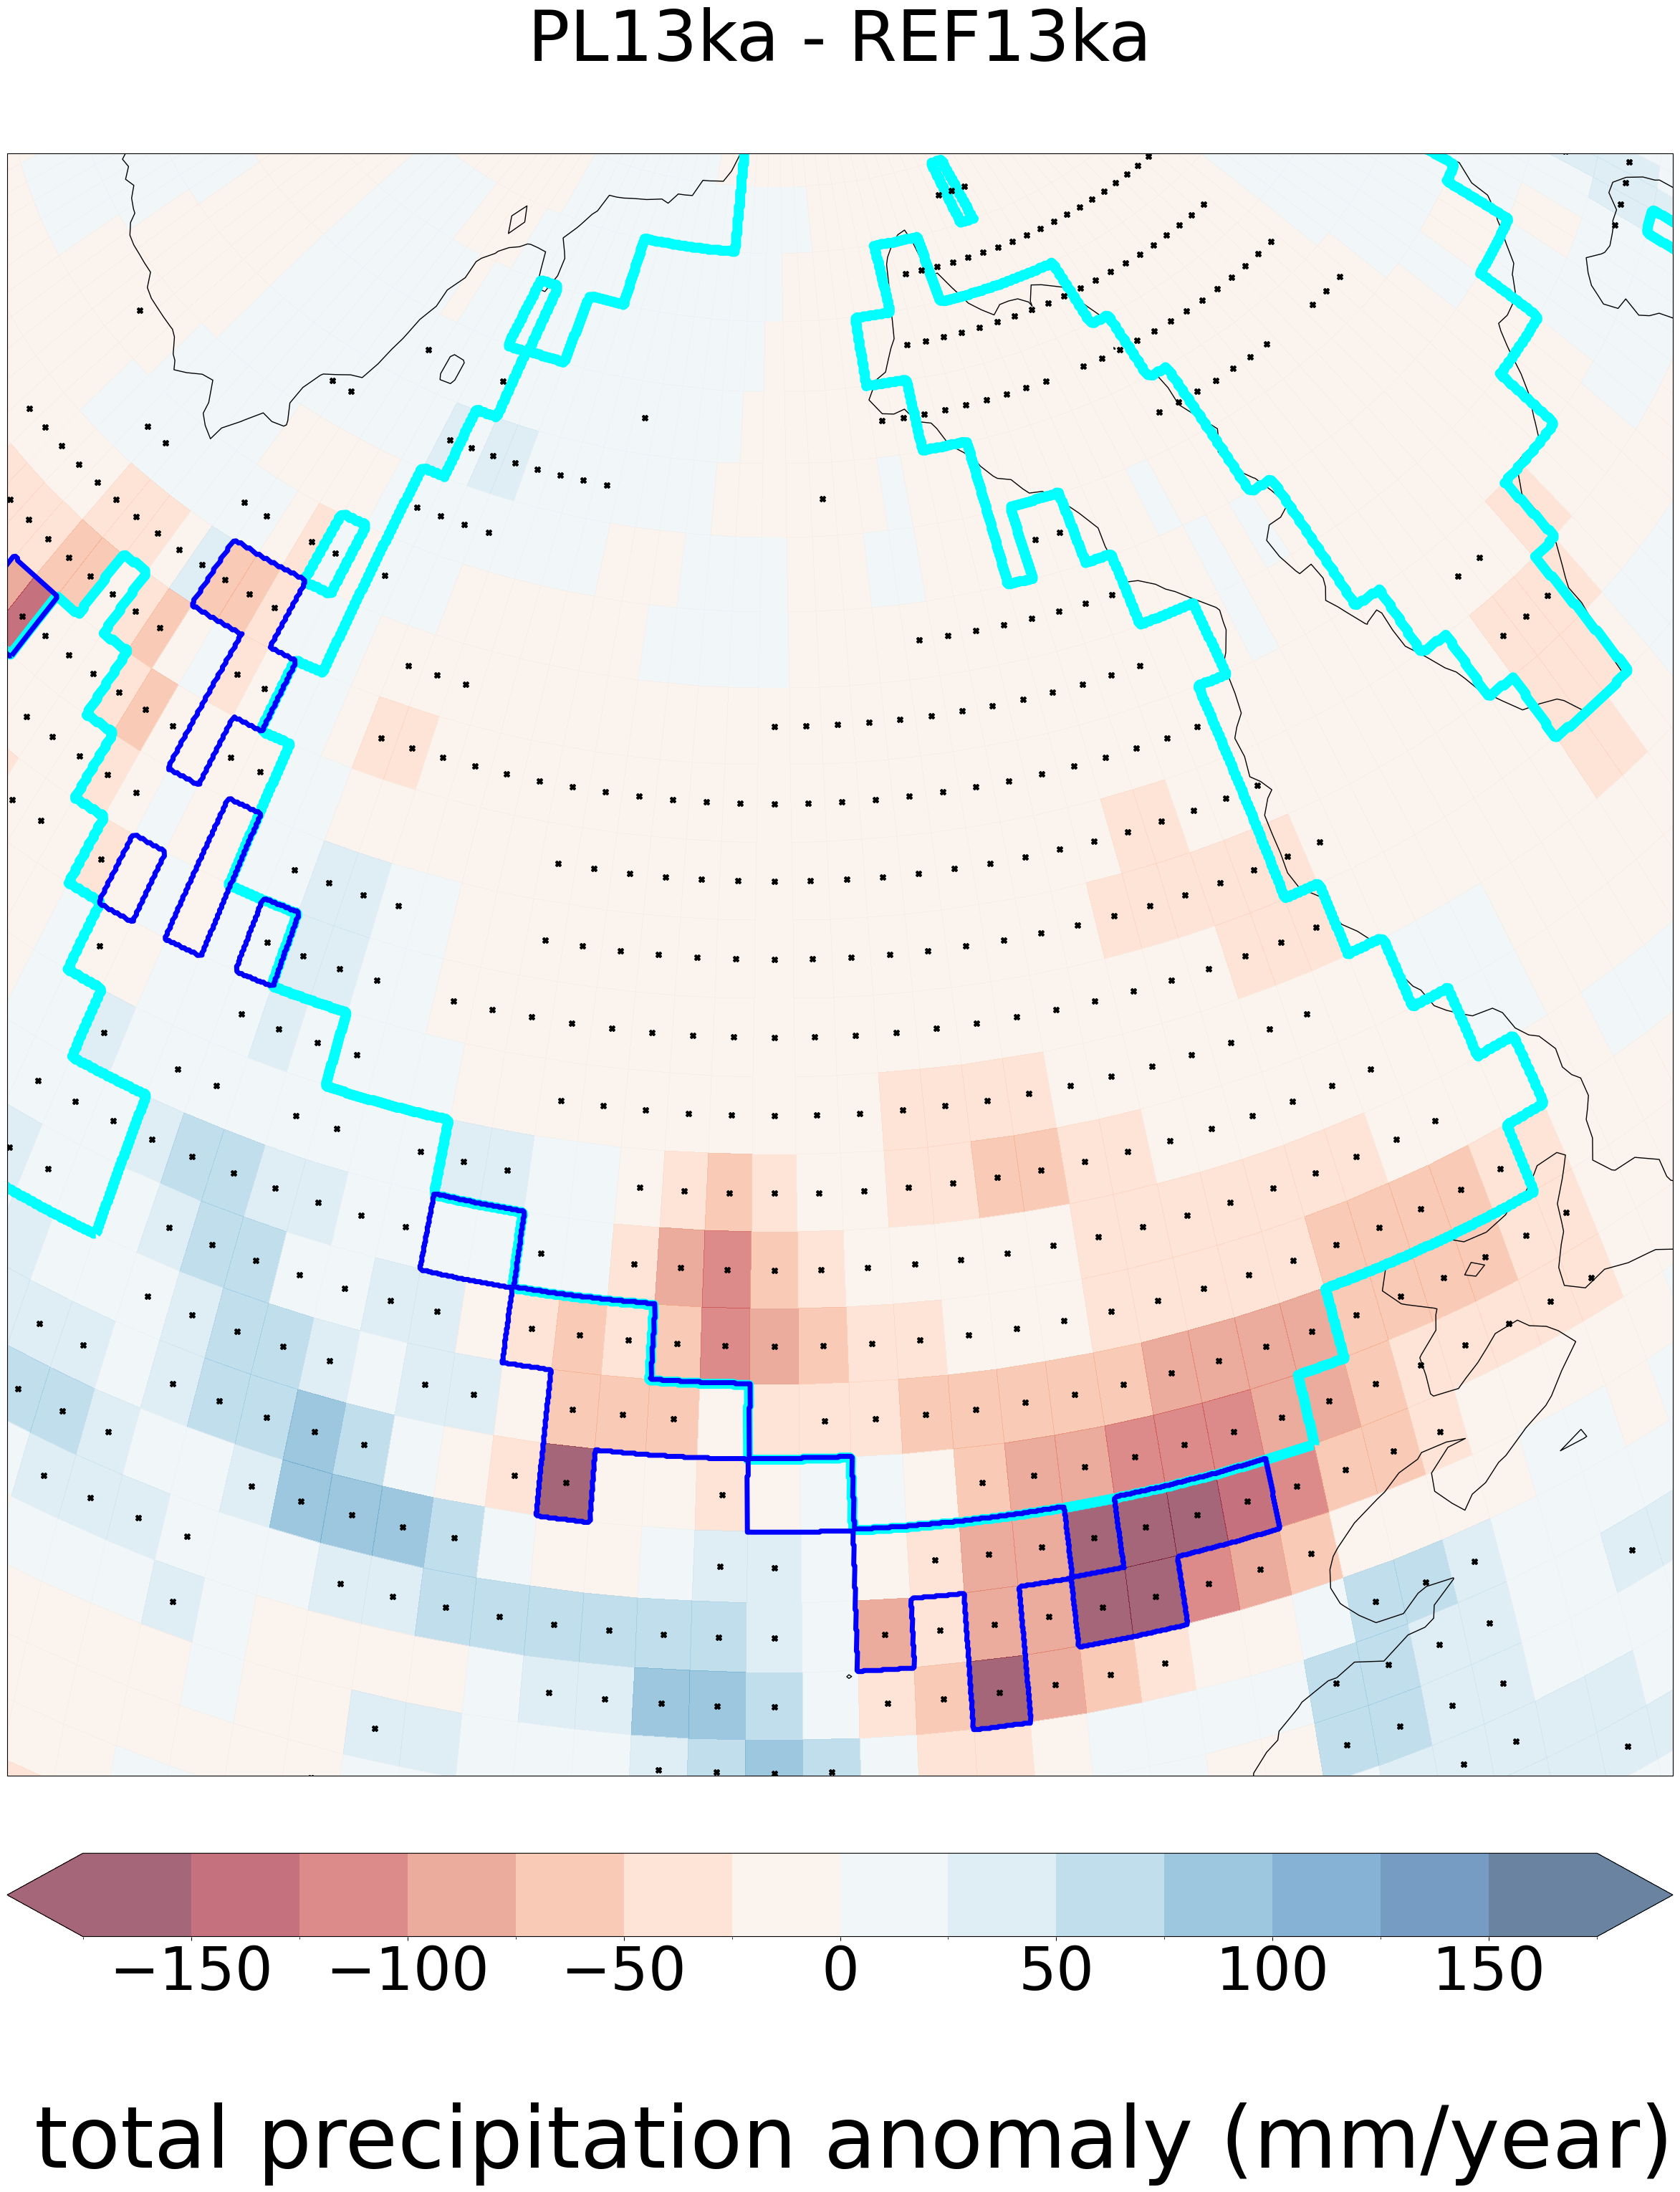

In [32]:
#read data

PLAKE='../data/100ymean_plake_precip_ym_2250_2349.nc'
PLAKE_data=netcdf_dataset(PLAKE)
GLACL='../data/100ymean_alakeGLAC_precip_ym_2250_2349.nc'
GLACL_data=netcdf_dataset(GLACL)

BC='../data/bc_plake_nhem5km.nc' 
BC_data=netcdf_dataset(BC)
BCL='../data/TOPicemsk.15ka.nc' 
BCL_data=netcdf_dataset(BCL)

PSIG='../data/PL_SigMaskSM.nc'
PSIG_data=netcdf_dataset(PSIG)
############################################
# create plot                              #
############################################


def makePlot(evar, clon, clat, extent, label):

    #Variable from alakeGLAC simulation (defined below)
    varp=PLAKE_data.variables[evar][0,:,:]
    varg=GLACL_data.variables[evar][0,:,:]
    lats=GLACL_data.variables['lat'][:] 
    lons=GLACL_data.variables['lon'][:]

    #jansurf input on 5km grid used for debm
    glac=BC_data.variables['GLAC'][:]
    plake=BC_data.variables['PLAKE'][:]
    lats5=BC_data.variables['lat'][:] 
    lons5=BC_data.variables['lon'][:]
    
    #levtarasov input
    slm=BCL_data.variables['HDC'][0,:,:]
    llats=BCL_data.variables['YLATGLOBP5'][:] 
    llons=BCL_data.variables['XLONGLOB1'][:]
    #significance mask
    vsigp=PSIG_data.variables['prcip_mask'][:,:]
    

    #creates figure space
    fig_gp=plt.figure(figsize=(30,35))  #option to add integer, 1 will add this number to the figure and hold this number as an attribute
    
    #adds charts to figure
    p01=plt.subplot(111,projection=ccrs.NearsidePerspective(central_longitude=clon, central_latitude=clat, satellite_height=10_000_000)) 
    
    #sets the extent
    p01.set_extent(extent)
    
    #for colors around 0
    divnorm = mcolors.TwoSlopeNorm(vmin=level_min, vcenter=0, vmax=level_max)
    
    
    ####################################
    #create anomaly for plake-alakeGLAC#
    ####################################
    
    
    #The following works with discrete colorbar, but has shitty ticks and no 0 in the middle
    bounds=np.linspace(level_min, level_max, 15)
    print(bounds)
    
    norm=mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
    
    p01_fill=p01.pcolormesh(lons, lats, varp-varg,
                            transform=ccrs.PlateCarree(),
                            norm=norm,
                            cmap="RdBu",
                            alpha=0.6,
                            edgecolor="none"
                           )

    
    p01_cbar=plt.colorbar(p01_fill, ax=p01,
                          orientation='horizontal',       
                          fraction=0.05, pad=0.04,
                          extend="both",
                          boundaries=bounds
                         )  
    
    ############
    #boundaries# 
    ############

    p01_slm=p01.contour(llons, llats, slm,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="black",
                        linewidths=1,
                        linestyles=["-"],
                        )        
    p01_gla=p01.contour(lons5, lats5, glac,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="cyan",
                        linewidths=10,
                        linestyles=["-"],
                        )  
    p01_plk=p01.contour(lons5, lats5, plake,
                        transform=ccrs.PlateCarree(),
                        levels=[0],
                        colors="blue",
                        linewidths=5,
                        linestyles=["-"],
                        #linestyles=["-."],
                        )
    for idx, lon_val in enumerate(lons):
        for idy, lat_val in enumerate(lats):
            if (vsigp[idy, idx]==0):
                p01.plot(lon_val, lat_val, 'kX',
                        transform=ccrs.PlateCarree())
    
                p01.set_title(" PL13ka - REF13ka \n"
                  "",
                  fontsize=70
                 )
    p01.set_title(" PL13ka - REF13ka \n"
                  "",
                  fontsize=70
                 )
    p01_cbar.ax.tick_params(labelsize=60)
    p01_cbar.set_label(label, fontsize=86)
    
    fig_gp.savefig('../FIGS/Fig2_6.png')
        
    return

var_extent= [-115,-60,35,80]
level_min=-175
level_max=175
#stepsize=25
#var_levels=np.arange(level_min,level_max,stepsize)
season="year"

makePlot(evar='precip', 
         clon=-90,
         clat=60, 
         extent=var_extent,
         label = "\n total precipitation anomaly (mm/"+season+")"
        )